#Algoritmos Particionales
Divide el conjunto de datos en grupos predefinidos, independientes y excluyentes. Ejemplo: Kmeans

##Kmeans

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [7]:
#Creando un conjunto de datos sintético

from sklearn.datasets import make_blobs #Esta opcion crea datos

X, y = make_blobs(n_samples=200, n_features=2, centers=4, cluster_std=0.7, random_state=42)
df = pd.DataFrame(X, columns=["x1","x2"])


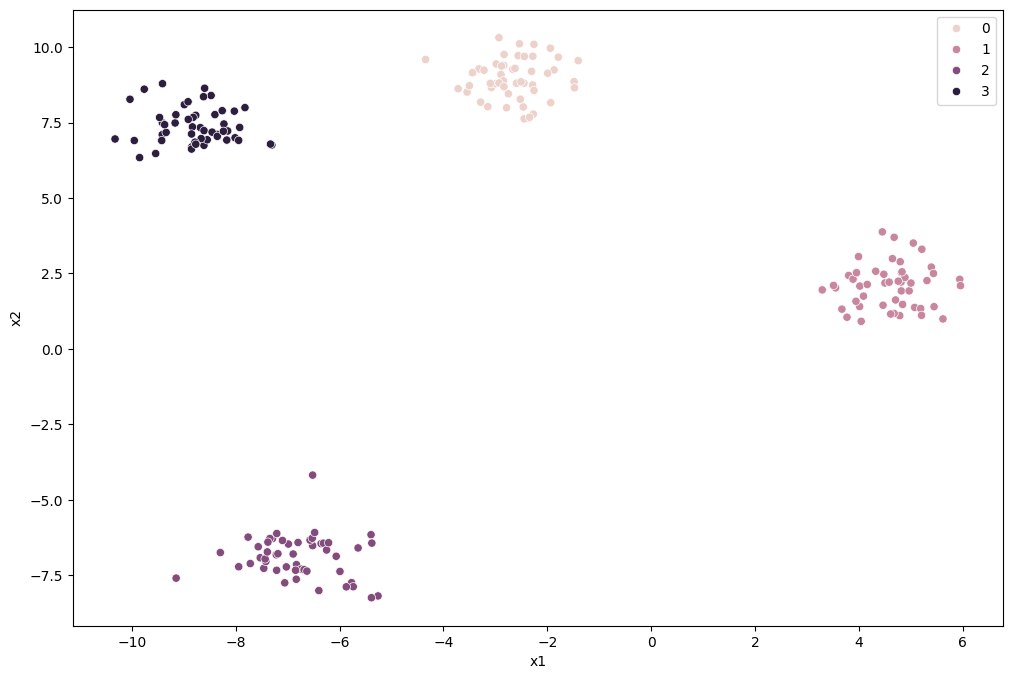

In [8]:
plt.figure(figsize=(12,8))
sns.scatterplot(data=df, x="x1", y="x2", hue=y) #Hue => tonalidad
plt.show()

Encontrando el mejor número k (Número de núcleos)

**Método del codo**

In [9]:
#para determinar el mejor valor de K

!pip install yellowbrick  #Es una metrica de error

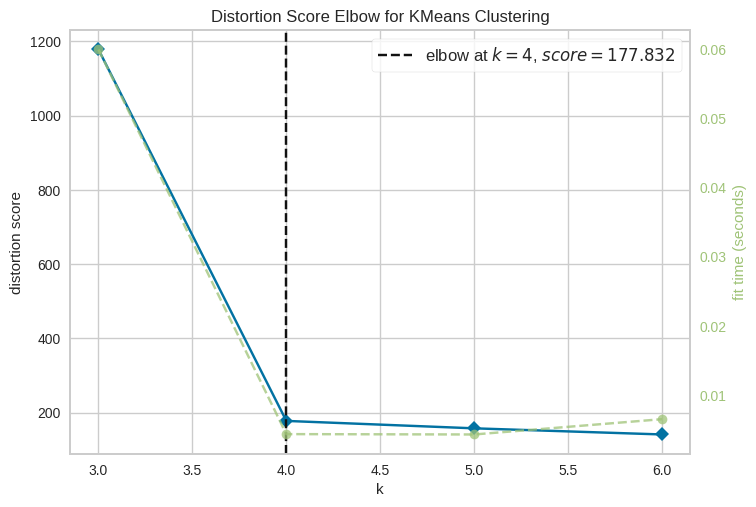

In [10]:
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans

model = KMeans()
visualizer = KElbowVisualizer(model, k=(3,7)) #Buscame el mejor entre k[tal  y tal]
visualizer.fit(df)
visualizer.show()
plt.show()

In [11]:
km = KMeans(n_clusters=4, random_state=42)
km.fit(df)
km.labels_ #Muestra las clases en cada registro

array([0, 1, 3, 3, 2, 2, 0, 3, 0, 2, 2, 0, 0, 2, 2, 2, 1, 3, 2, 2, 2, 2,
       3, 1, 3, 1, 1, 2, 1, 0, 2, 2, 3, 3, 1, 0, 3, 0, 3, 1, 2, 1, 2, 2,
       3, 0, 0, 2, 0, 1, 3, 1, 3, 0, 1, 1, 2, 2, 1, 0, 3, 0, 2, 3, 3, 2,
       0, 1, 3, 1, 1, 3, 1, 2, 0, 2, 0, 1, 2, 1, 1, 0, 2, 3, 3, 3, 3, 1,
       0, 3, 2, 1, 0, 0, 0, 3, 1, 0, 2, 1, 3, 3, 1, 2, 1, 0, 3, 2, 2, 3,
       0, 2, 1, 3, 1, 3, 3, 1, 1, 1, 3, 2, 0, 3, 3, 0, 1, 0, 0, 1, 2, 2,
       1, 3, 3, 0, 2, 2, 1, 2, 0, 1, 3, 0, 0, 1, 0, 3, 2, 2, 1, 3, 0, 3,
       2, 3, 3, 0, 0, 0, 1, 0, 0, 3, 1, 2, 0, 0, 2, 0, 3, 1, 2, 2, 0, 2,
       0, 1, 1, 2, 1, 2, 3, 3, 3, 1, 0, 0, 0, 1, 1, 2, 3, 3, 1, 3, 0, 1,
       2, 0], dtype=int32)

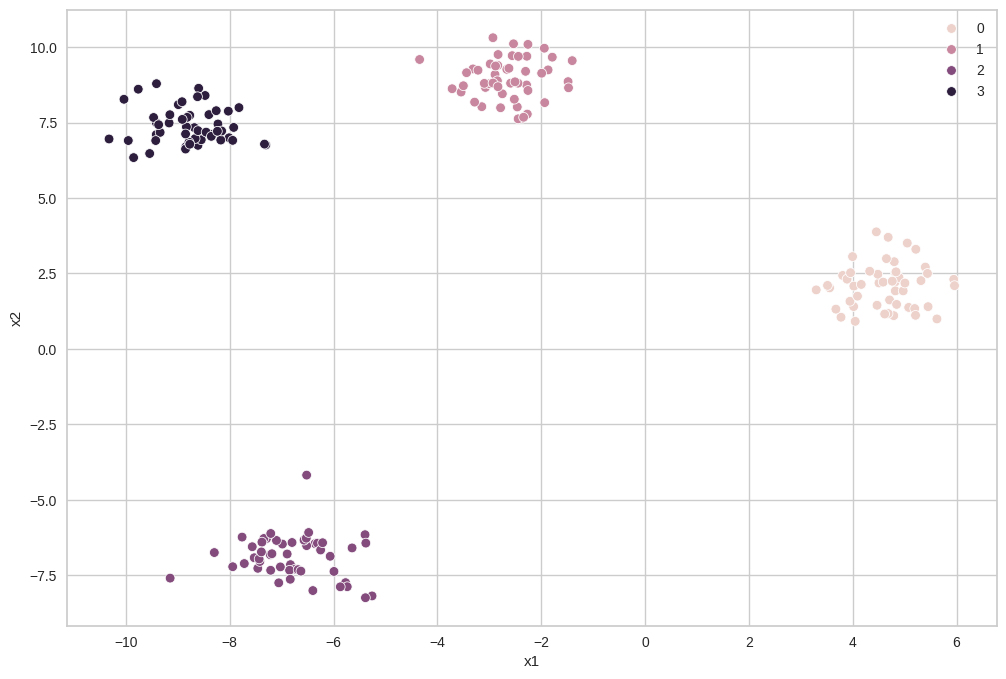

In [12]:
plt.figure(figsize=(12,8))
sns.scatterplot(data=df, x="x1", y="x2", hue=km.labels_) #En lugar de saturacion, usa los valores de las etiquetas
plt.show()

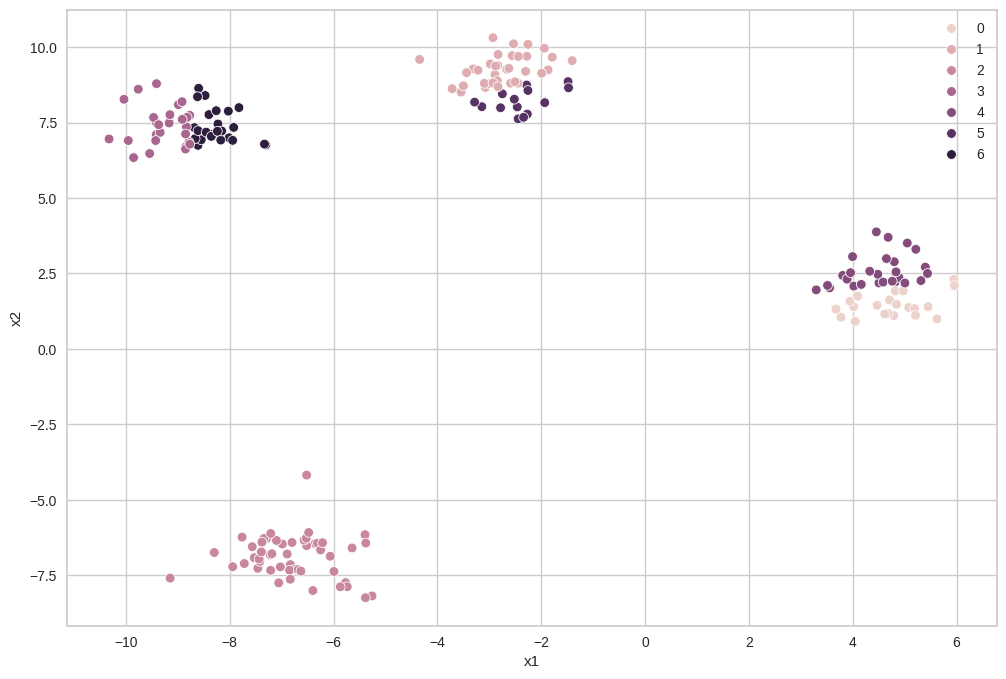

In [13]:
km = KMeans(n_clusters=7, random_state=42)
km.fit(df)
km.labels_
plt.figure(figsize=(12,8))
sns.scatterplot(data=df, x="x1", y="x2", hue=km.labels_)
plt.show()

In [14]:
km.cluster_centers_ #Este es el centroide de los 7 grupos que he elegido

array([[ 4.75769762,  1.44900117],
       [-2.7543229 ,  9.26238698],
       [-6.79168528, -6.88664699],
       [-9.26907209,  7.38753084],
       [ 4.48721446,  2.55788189],
       [-2.38586407,  8.17543351],
       [-8.24216215,  7.37695563]])

#Coeficiente de silueta

Nos permite ver la calidad intracluster e intercluster. Esto es:
* **Intracluster** (*densidad*, *cohesión*) se refiere a la cercanía de los elementos de la misma clase entre si.
* **Intercluster** (*separación*) se refiere a la separación entre grupos diferentes.

Se calcula como la diferencia entre la distancia promedio dentro del grupo y la distancia media del grupo más cercano para cada muestra, normalizada por el valor máximo.

Esto va a producir un resultado entre -1 y +1, donde las puntuaciones más cercanas a +1 indican separación alta y las puntuaciones cercanas a -1 indican que es posible que las muestras se hayan asignado a un cluster incorrecto.

En Yellowbrick, existe un SilhouetteVisualizer donde los clusters con puntajes más altos tienen siluetas más anchas y los clusters que son menos cohesos no alcanzarán el puntaje primedio en todos lo grupos, que se representa como una línea roja punteada vertical.


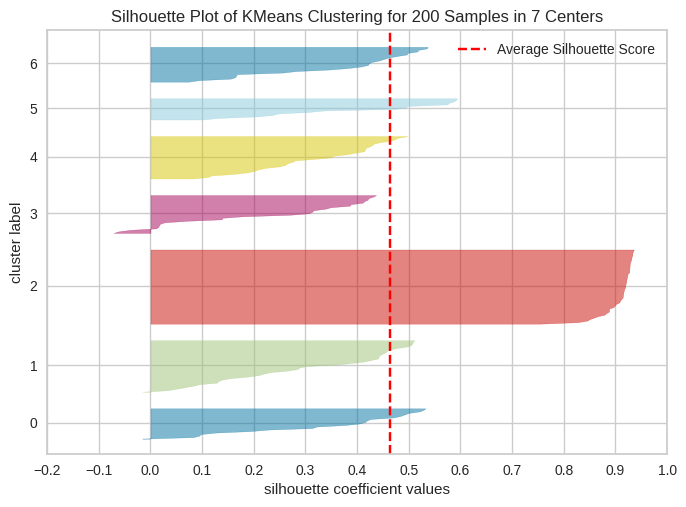

In [15]:
from yellowbrick.cluster import SilhouetteVisualizer

km = KMeans(n_clusters=7, random_state=42)
visualizer = SilhouetteVisualizer(km, colors="yellowbrick")
visualizer.fit(df)
visualizer.show()
plt.show()

# NUestros clustes que tienen una silhueta más ancha, son clusters mejor formados.
# Los clusters que no pasan del promedio, están mál formados

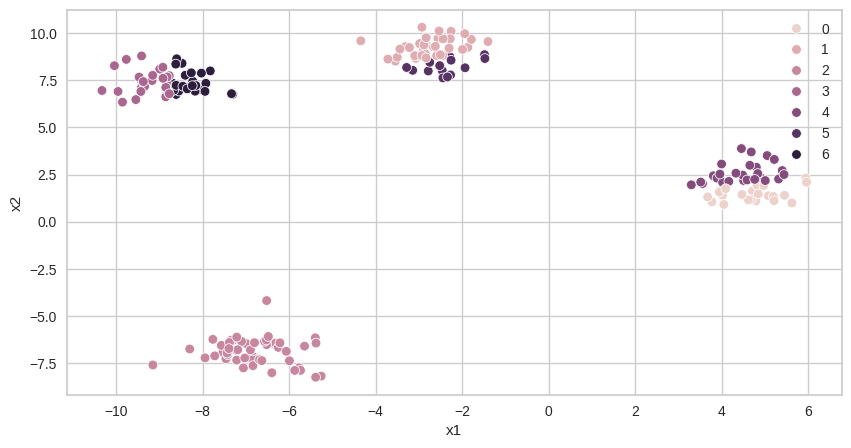

In [16]:
plt.figure(figsize=(10,5))
sns.scatterplot(data=df, x="x1", y ="x2", hue=km.labels_)
plt.show()

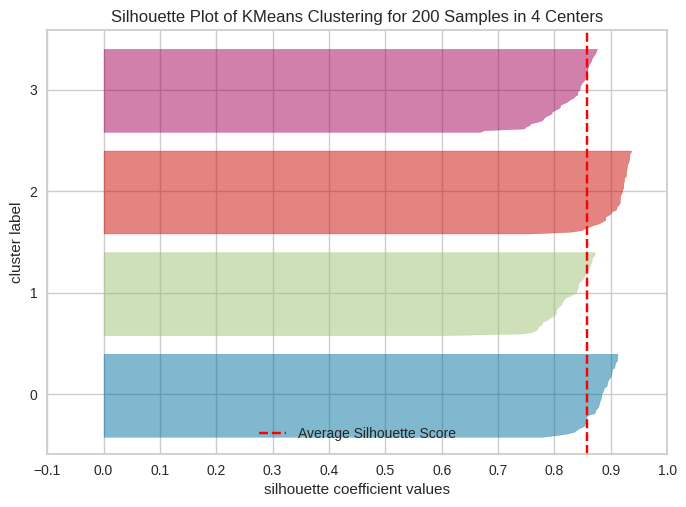

In [17]:
from yellowbrick.cluster import SilhouetteVisualizer

km = KMeans(n_clusters=4, random_state=42)
visualizer = SilhouetteVisualizer(km, colors="yellowbrick")
visualizer.fit(df)
visualizer.show()
plt.show()

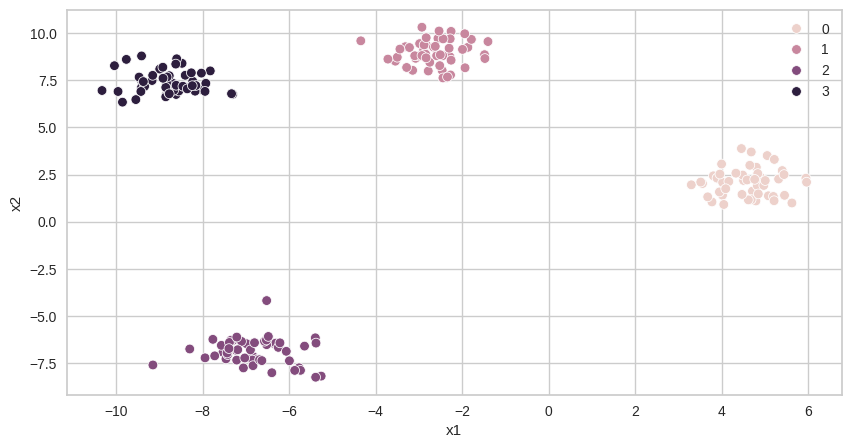

In [18]:
plt.figure(figsize=(10,5))
sns.scatterplot(data=df, x="x1", y ="x2", hue=km.labels_)
plt.show()

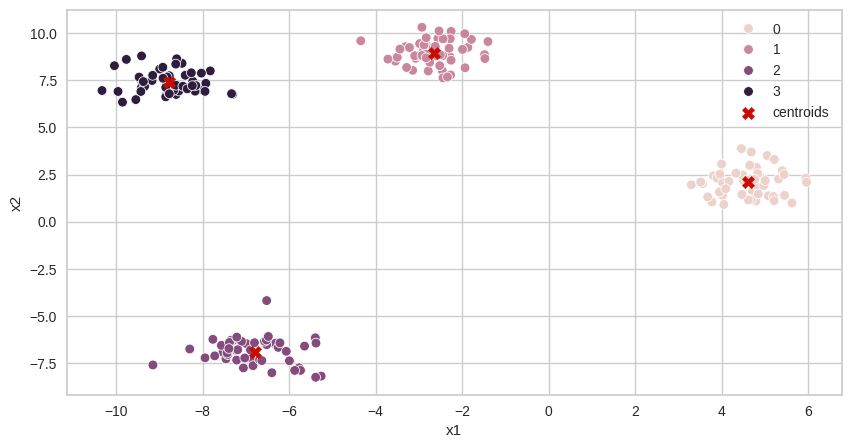

In [19]:
plt.figure(figsize=(10,5))
sns.scatterplot(data=df, x="x1", y ="x2", hue=km.labels_)
plt.scatter(km.cluster_centers_[:,0], km.cluster_centers_[:,1], marker="X", c="r", s=80, label="centroids") #Pasando los centroides
plt.legend()
plt.show()

#Métricas de Clustering

In [20]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

#Suma de los cuadrados de las distancias de las muestras a su centroide más cercano. Esto es llamado también de Inercia. Es usado para el método del codo.
print("Inercia, SSE:", km.inertia_)

#Coeficiente de silueta que evalúa la cohesión en cada cluster y la separabilidad entre clusters
print("Silhouette Score:", silhouette_score(df, km.labels_, metric="euclidean"))

#Davies es el promedio de cada cluster con su cluster más similar
print("Davis Scores:", davies_bouldin_score(df, km.labels_))

# Resultados:
# - El resulado de insercia es el más bajo (177)
# - El valor de siluetas es bueno porque se acerca a 1 (0.8)


Inercia, SSE: 177.83236142097877
Silhouette Score: 0.8578663887913746
Davis Scores: 0.19605872174118094


#Algoritmos Jerárquicos
Estructura de árbol. Por ejemplo Dendograma, Cluster jerárquico

In [21]:
dataset = pd.read_csv('https://raw.githubusercontent.com/aurea-soriano/MJ-DataScienceTeam/main/biblioteca/3_aprendizaje_no_supervisado/clustering/Mall_Customers.csv')
dataset.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [22]:
X = dataset.iloc[:,[3,4]].values
print(X.shape)

(200, 2)


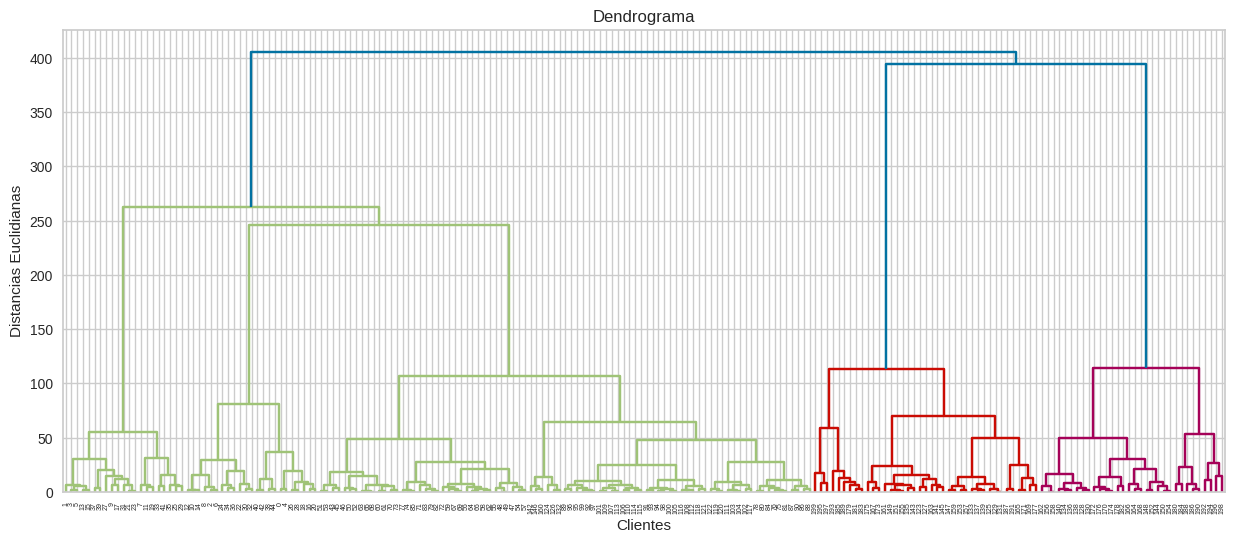

In [23]:
import scipy.cluster.hierarchy as sch

plt.figure(figsize=(15,6))
plt.title("Dendrograma")
plt.xlabel("Clientes")
plt.ylabel("Distancias Euclidianas")

dendrogram = sch.dendrogram(sch.linkage(X, method="ward")) #Ward usa distancias
plt.show()

### Número óptimo de clústeres

A menudo, el número óptimo de clusters se puede encontrar en un dendograma de una manera sencilla.
* Busque el tramo más largo de línea vertical que *no esté cruzado por ninguna línea horizontal* ***extendida*** (aquí *extendido* significa líneas horizontales, es decir, los divisores de grupos se extienden infinitamente en ambas direcciones).
* Ahora toma cualquier punto de ese tramo de línea y dibuja una línea horizontal imaginaria.
* Cuenta cuántas líneas verticales cruzaron estas líneas imaginarias.
* Es probable que ese sea el número óptimo de clústeres.

**La idea se muestra en la siguiente figura. Aquí, el número óptimo de clústeres podría ser 5.**

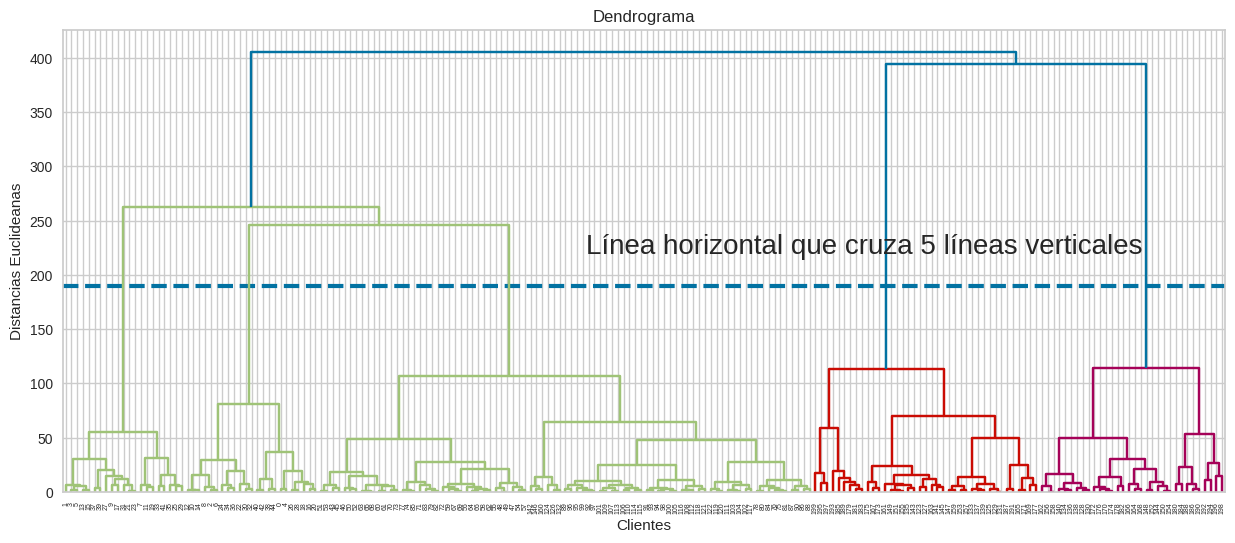

In [24]:
plt.figure(figsize=(15,6))
plt.title('Dendrograma')
plt.xlabel('Clientes')
plt.ylabel('Distancias Euclideanas')
plt.hlines(y=190,xmin=0,xmax=2000,lw=3,linestyles='--')
plt.text(x=900,y=220,s='Línea horizontal que cruza 5 líneas verticales',fontsize=20)
#plt.grid(True)
dendrogram = sch.dendrogram(sch.linkage(X, method = 'ward'))
plt.show()

In [26]:
from sklearn.cluster import AgglomerativeClustering
X = dataset.iloc[:,[3,4]].values
hc = AgglomerativeClustering(n_clusters=5, linkage="complete")

hc.fit(X)
y_hc = hc.labels_

#y_hc = hc.fit_transform(X) #Funciona lo mismo de las dos lineas ante

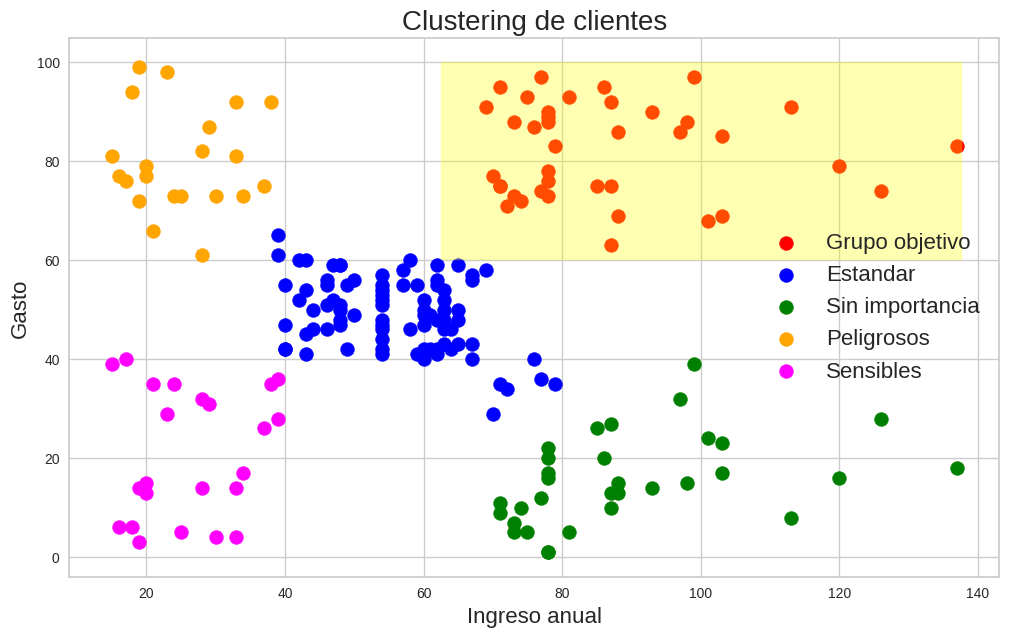

In [27]:
plt.figure(figsize=(12,7))
plt.scatter(X[y_hc == 0, 0], X[y_hc == 0, 1], s = 100, c = 'red', label ="Grupo objetivo")
plt.scatter(X[y_hc == 1, 0], X[y_hc == 1, 1], s = 100, c = 'blue', label ="Estandar")
plt.scatter(X[y_hc == 2, 0], X[y_hc == 2, 1], s = 100, c = 'green', label ="Sin importancia")
plt.scatter(X[y_hc == 3, 0], X[y_hc == 3, 1], s = 100, c = 'orange', label ="Peligrosos")
plt.scatter(X[y_hc == 4, 0], X[y_hc == 4, 1], s = 100, c = 'magenta', label = "Sensibles")
plt.title("Clustering de clientes", fontsize=20)
plt.xlabel("Ingreso anual", fontsize=16)
plt.ylabel("Gasto", fontsize=16)
plt.legend(fontsize=16)
plt.grid(True)
plt.axhspan(ymin=60,ymax=100,xmin=0.4,xmax=0.96,alpha=0.3,color='yellow') #Crea los rectangulos para resaltar alguna parte de la visualizacion
plt.show()

Etiquetar los tipos de clientes:

1. Clientes estándar: Ingresos medios y gastos medios
2. Clientes sensibles: Ingresos bajos y gastos bajos
3. Clientes peligrosos: Ingresos bajos y gastos altos (debe evitarse debido al posible riesgo crediticio)
4. Clientes sin importancia: Ingresos altos y gastos bajos
5. Clientes objetivo: Ingresos altos y gastos altos (debe ser el objetivo del mall).

# Clustering de Densidad: DBSCAN

El algoritmo [DBSCAN](http://scikit-learn.org/stable/modules/clustering.html#dbscan) ve los clústeres como áreas de alta densidad separadas por áreas de baja densidad.

Debido a esta vista bastante genérica, los grupos encontrados por DBSCAN pueden tener cualquier forma, a diferencia de k-means, que asume que los grupos tienen forma convexa.

**Core**: Son puntos que tienen al menos una cantidad de minpts a su alrededor.
**Border**: Son puntos que no tienen los minpts a su alrededor pero si forman parte del área determinada por un *Core*.
**Noise**: Son puntos que no pertenecen a *Border* ni a *Core*

![dbscan](https://3.bp.blogspot.com/-rDYuyg00Z0w/WXA-OQpkAfI/AAAAAAAAI_I/QshfNVNHD_wXJwXEipRIVzDSX5iOEAy2wCEwYBhgL/s1600/DBSCAN_Points.PNG)

Link de video: https://youtu.be/METJ9ItzD10?si=jziyeaR4K4D7zebH


In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Como DBScan funciona con datos que no tienen formas globulares, vamos a crear conjuntos artificiales de forma de luna y de donnuts.


In [30]:
from sklearn import cluster, datasets

n_samples = 1500
noisy_circles, circle_labels = datasets.make_circles(n_samples=n_samples, factor=0.5, noise=0.05)
noisy_moons, moon_labels = datasets.make_moons(n_samples=n_samples, noise=0.1)

noisy_moons = np.array(noisy_moons)
noisy_circles = np.array(noisy_circles)

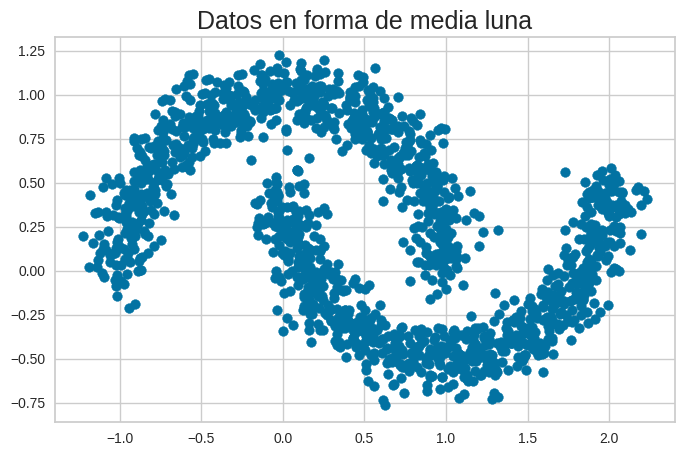

In [31]:
plt.figure(figsize=(8,5))
plt.title("Datos en forma de media luna", fontsize=18)
plt.grid(True)
plt.scatter(noisy_moons[:,0], noisy_moons[:,1])
plt.show()

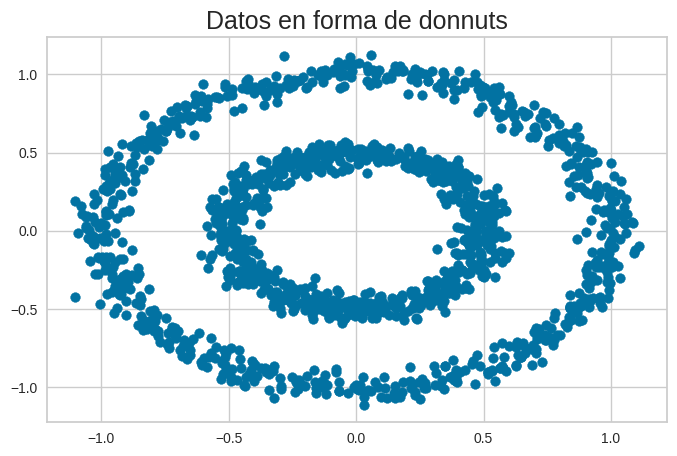

In [32]:
plt.figure(figsize=(8,5))
plt.title("Datos en forma de donnuts", fontsize=18)
plt.grid(True)
plt.scatter(noisy_circles[:,0], noisy_circles[:,1])
plt.show()

Resultados con K-means

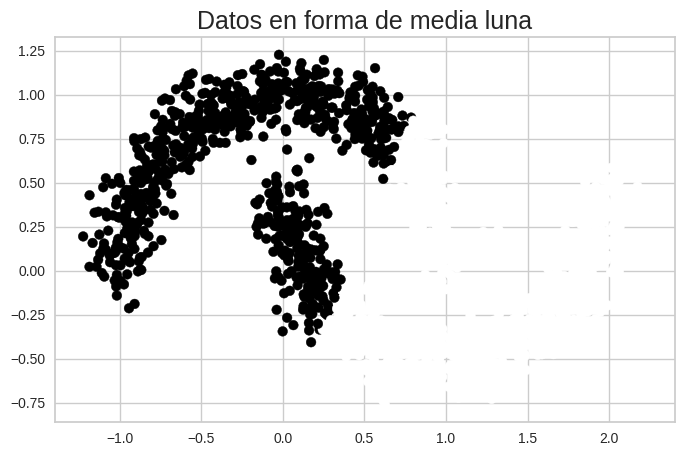

In [33]:
km = cluster.KMeans(n_clusters=2)
km.fit(noisy_moons)

plt.figure(figsize=(8,5))
plt.title("Datos en forma de media luna", fontsize=18)
plt.grid(True)
plt.scatter(noisy_moons[:,0], noisy_moons[:,1], c=km.labels_)
plt.show()

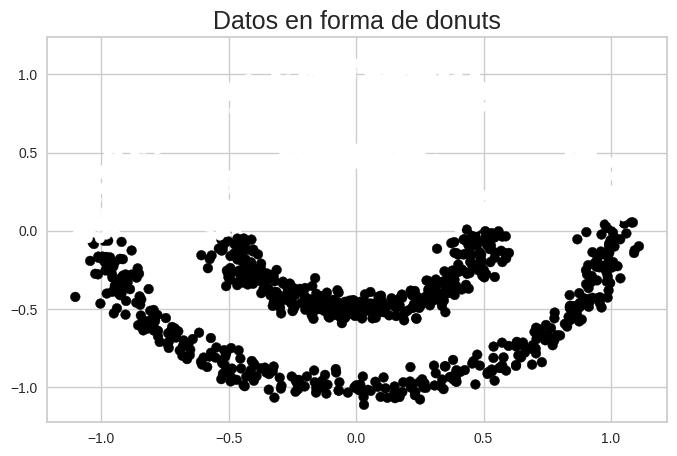

In [34]:
km.fit(noisy_circles)

plt.figure(figsize=(8,5))
plt.title("Datos en forma de donuts", fontsize=18)
plt.grid(True)
plt.scatter(noisy_circles[:,0], noisy_circles[:,1], c=km.labels_)
plt.show()

DBScan

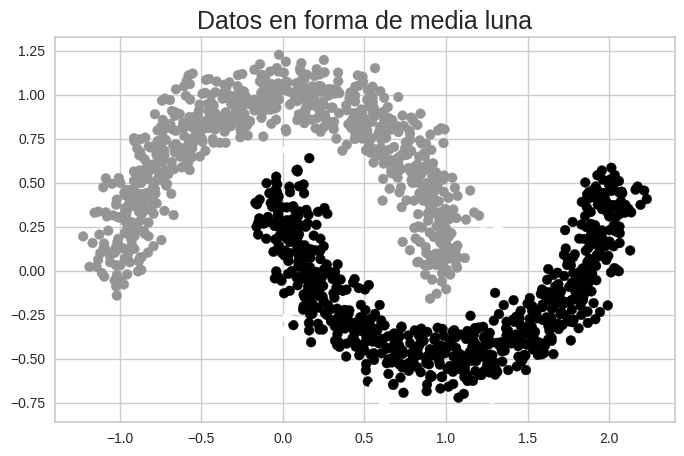

In [35]:
dbs = cluster.DBSCAN(eps=0.1)
dbs.fit(noisy_moons)

plt.figure(figsize=(8,5))
plt.title("Datos en forma de media luna", fontsize=18)
plt.grid(True)
plt.scatter(noisy_moons[:,0], noisy_moons[:,1], c=dbs.labels_)
plt.show()

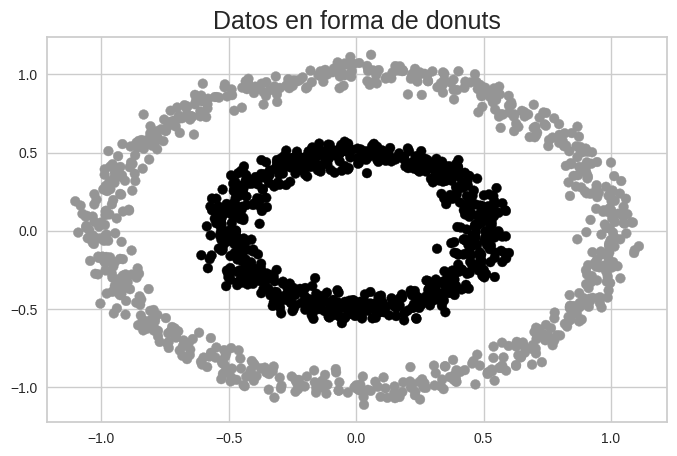

In [36]:
dbs = cluster.DBSCAN(eps=0.1, min_samples=2)
dbs.fit(noisy_circles)

plt.figure(figsize=(8,5))
plt.title("Datos en forma de donuts", fontsize=18)
plt.grid(True)
plt.scatter(noisy_circles[:,0], noisy_circles[:,1], c=dbs.labels_)
plt.show()

#Métricas de clustering: Coeficiente de Siluete, Davies Bouldin, v_measure

In [37]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, v_measure_score

#coeficiente de silueta

#kmeans - Donnuts
km = cluster.KMeans(n_clusters=2)
km.fit(noisy_circles)
print("Coeficiente de Silueta - Donnuts - Kmeans:", silhouette_score(noisy_circles, km.labels_))

#dbscan - donnuts
dbs = cluster.DBSCAN(eps=0.1, min_samples=2)
dbs.fit(noisy_circles)
print("Coeficiente de Silueta - Donnuts - Dbscan:", silhouette_score(noisy_circles, dbs.labels_))



#kmeans - lunas
km = cluster.KMeans(n_clusters=2)
km.fit(noisy_moons)
print("Coeficiente de Silueta - lunas - Kmeans:", silhouette_score(noisy_moons, km.labels_))

#dbscan - lunas
dbs = cluster.DBSCAN(eps=0.1, min_samples=2)
dbs.fit(noisy_moons)
print("Coeficiente de Silueta - lunas - Dbscan:", silhouette_score(noisy_moons, dbs.labels_))


Coeficiente de Silueta - Donnuts - Kmeans: 0.3511580987723543
Coeficiente de Silueta - Donnuts - Dbscan: 0.08030550439098216
Coeficiente de Silueta - lunas - Kmeans: 0.48259043788331374
Coeficiente de Silueta - lunas - Dbscan: -0.09158689573515713


Vemos para el ejemplo de donas, KMeans aparentemente tiene un mejor comportamiento; pero sabemos que no es así. Por lo tanto, el análisis está siendo complejo para el método de la Silueta

In [38]:
#davies_bouldin_score

#kmeans - Donnuts
km = cluster.KMeans(n_clusters=2)
km.fit(noisy_circles)
print("davies_bouldin_score - Donnuts - Kmeans:", davies_bouldin_score(noisy_circles, km.labels_))

#dbscan - donnuts
dbs = cluster.DBSCAN(eps=0.1, min_samples=2)
dbs.fit(noisy_circles)
print("davies_bouldin_score - Donnuts - Dbscan:", davies_bouldin_score(noisy_circles, dbs.labels_))



#kmeans - lunas
km = cluster.KMeans(n_clusters=2)
km.fit(noisy_moons)
print("davies_bouldin_score - lunas - Kmeans:", davies_bouldin_score(noisy_moons, km.labels_))

#dbscan - lunas
dbs = cluster.DBSCAN(eps=0.1, min_samples=2)
dbs.fit(noisy_moons)
print("davies_bouldin_score - lunas - Dbscan:", davies_bouldin_score(noisy_moons, dbs.labels_))


davies_bouldin_score - Donnuts - Kmeans: 1.1854346415070915
davies_bouldin_score - Donnuts - Dbscan: 163.4540502254986
davies_bouldin_score - lunas - Kmeans: 0.7890321895865469
davies_bouldin_score - lunas - Dbscan: 2.548654763788375


Utilizando davis_bouldin, mientras haya más diferencia con los clusters, el resultado es mejor, así que, de esta vez, la métrica apunta correctamente al mejor método.

In [39]:
#Ejemplo de datos de blobs

from sklearn.datasets import make_blobs

data = make_blobs(n_samples=200, n_features=2, centers=2, cluster_std=1.2)

X = data[0]
print(X.shape)

(200, 2)


In [40]:
df = pd.DataFrame(data=X, columns=["Feature_"+str(i) for i in range(1, 3)]) #range(A, B) el range va desde A incluyendo A hasta B sin incluir B
df.head()

,Feature_1,Feature_2
0,3.807795,-4.372780
1,2.907117,-4.899943
2,2.972666,-3.848856
3,-1.427951,-0.734930
4,4.207692,-4.715916


In [41]:
y = data[1]
print(y)

[1 1 1 0 1 1 1 1 0 0 0 0 1 1 1 1 1 1 0 0 0 1 0 1 1 0 1 0 1 1 1 0 0 0 0 0 1
 1 0 0 1 1 0 0 1 0 1 1 1 1 1 0 1 0 1 1 0 1 0 1 0 1 0 0 0 1 1 0 1 0 1 0 0 1
 1 0 1 0 0 0 1 0 1 1 1 0 1 1 0 1 0 1 0 0 1 0 0 1 0 0 1 0 1 0 1 1 0 1 0 1 1
 0 0 0 0 0 0 0 0 1 1 1 1 0 1 0 1 0 1 1 0 0 0 0 0 0 1 1 1 0 1 1 0 1 1 0 1 1
 0 0 1 0 1 0 1 1 1 0 0 0 1 0 1 1 0 0 0 0 1 1 0 0 0 0 0 0 1 0 0 0 1 0 0 1 0
 1 0 1 0 1 1 1 1 1 0 1 0 1 1 0]


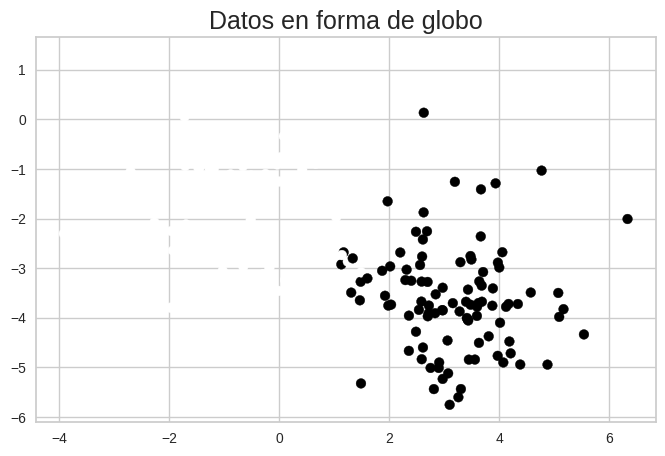

In [42]:

plt.figure(figsize=(8,5))
plt.title("Datos en forma de globo", fontsize=18)
plt.grid(True)
plt.scatter(X[:,0], X[:,1], c=y)
plt.show()

v_measure_score - Globo - Kmeans: 0.832041673919063
Coeficiente de Silueta - Globo - Kmeans: 0.5637319943120856


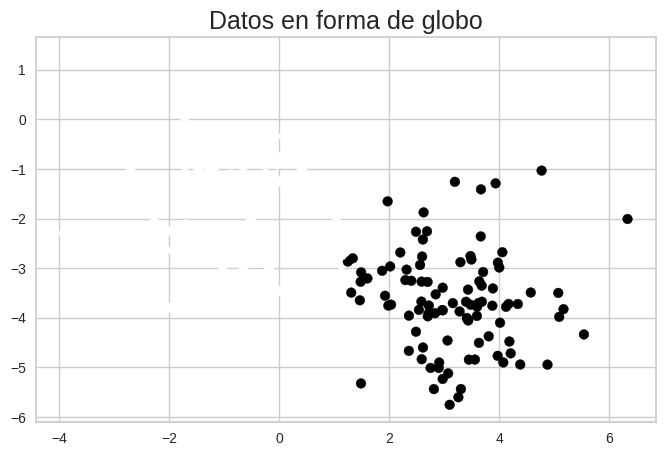

In [43]:
#v_measure_score

#kmeans - Donnuts
km = cluster.KMeans(n_clusters=2)
km.fit(X)
print("v_measure_score - Globo - Kmeans:", v_measure_score(y, km.labels_))
print("Coeficiente de Silueta - Globo - Kmeans:", silhouette_score(X, km.labels_))


plt.figure(figsize=(8,5))
plt.title("Datos en forma de globo", fontsize=18)
plt.grid(True)
plt.scatter(X[:,0], X[:,1], c=km.labels_)
plt.show()


v_measure_score - Globo - Dbscan: 0.4117320763551786
Coeficiente de Silueta - Globo - Dbscan: -0.08807449052298841


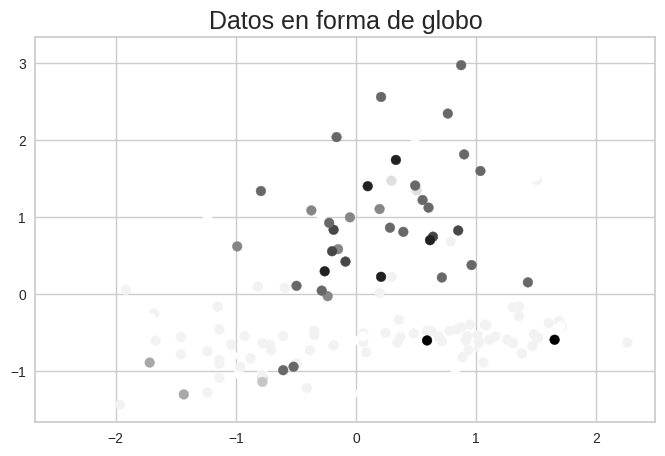

In [60]:

#dbscan - globo
dbs = cluster.DBSCAN(eps=2, min_samples=2)
dbs.fit(X)
print("v_measure_score - Globo - Dbscan:", v_measure_score(y, dbs.labels_))
print("Coeficiente de Silueta - Globo - Dbscan:", silhouette_score(X, dbs.labels_))

plt.figure(figsize=(8,5))
plt.title("Datos en forma de globo", fontsize=18)
plt.grid(True)
plt.scatter(X[:,0], X[:,1], c=dbs.labels_)
plt.show()


#Reducción de Dimensionalidad

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [46]:
df = pd.read_csv('https://raw.githubusercontent.com/aurea-soriano/ML-Datasets/master/wine.data.csv')
df.head(10)



,Class,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
5,1,14.20,1.76,2.45,15.2,112,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450
6,1,14.39,1.87,2.45,14.6,96,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290
7,1,14.06,2.15,2.61,17.6,121,2.60,2.51,0.31,1.25,5.05,1.06,3.58,1295
8,1,14.83,1.64,2.17,14.0,97,2.80,2.98,0.29,1.98,5.20,1.08,2.85,1045
9,1,13.86,1.35,2.27,16.0,98,2.98,3.15,0.22,1.85,7.22,1.01,3.55,1045


In [47]:
print(len(df.columns))

14


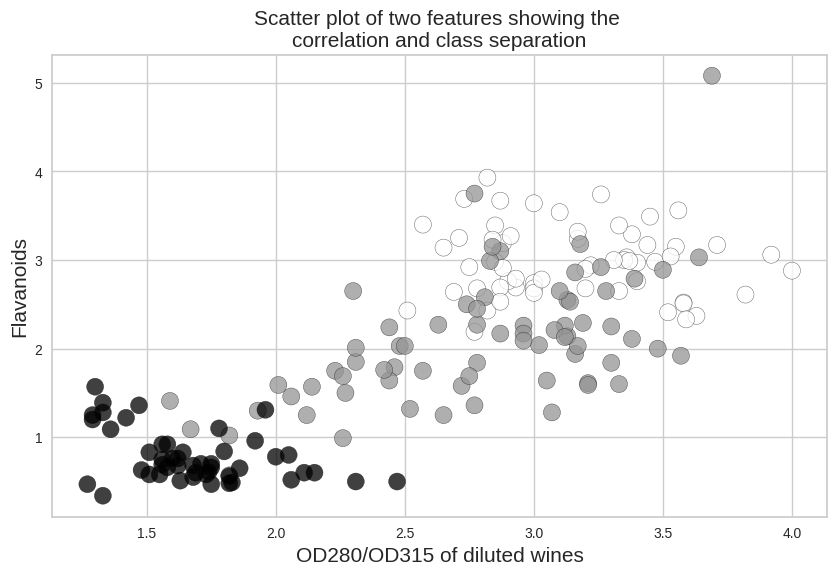

In [48]:
plt.figure(figsize=(10,6))
plt.scatter(df['OD280/OD315 of diluted wines'],df['Flavanoids'],c=df['Class'],edgecolors='k',alpha=0.75,s=150)
plt.grid(True)
plt.title("Scatter plot of two features showing the \ncorrelation and class separation",fontsize=15)
plt.xlabel("OD280/OD315 of diluted wines",fontsize=15)
plt.ylabel("Flavanoids",fontsize=15)
plt.show()

/tmp/ipykernel_3406/243453185.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('jet', 30)
/tmp/ipykernel_3406/243453185.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(labels,fontsize=9)
/tmp/ipykernel_3406/243453185.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels(labels,fontsize=9)


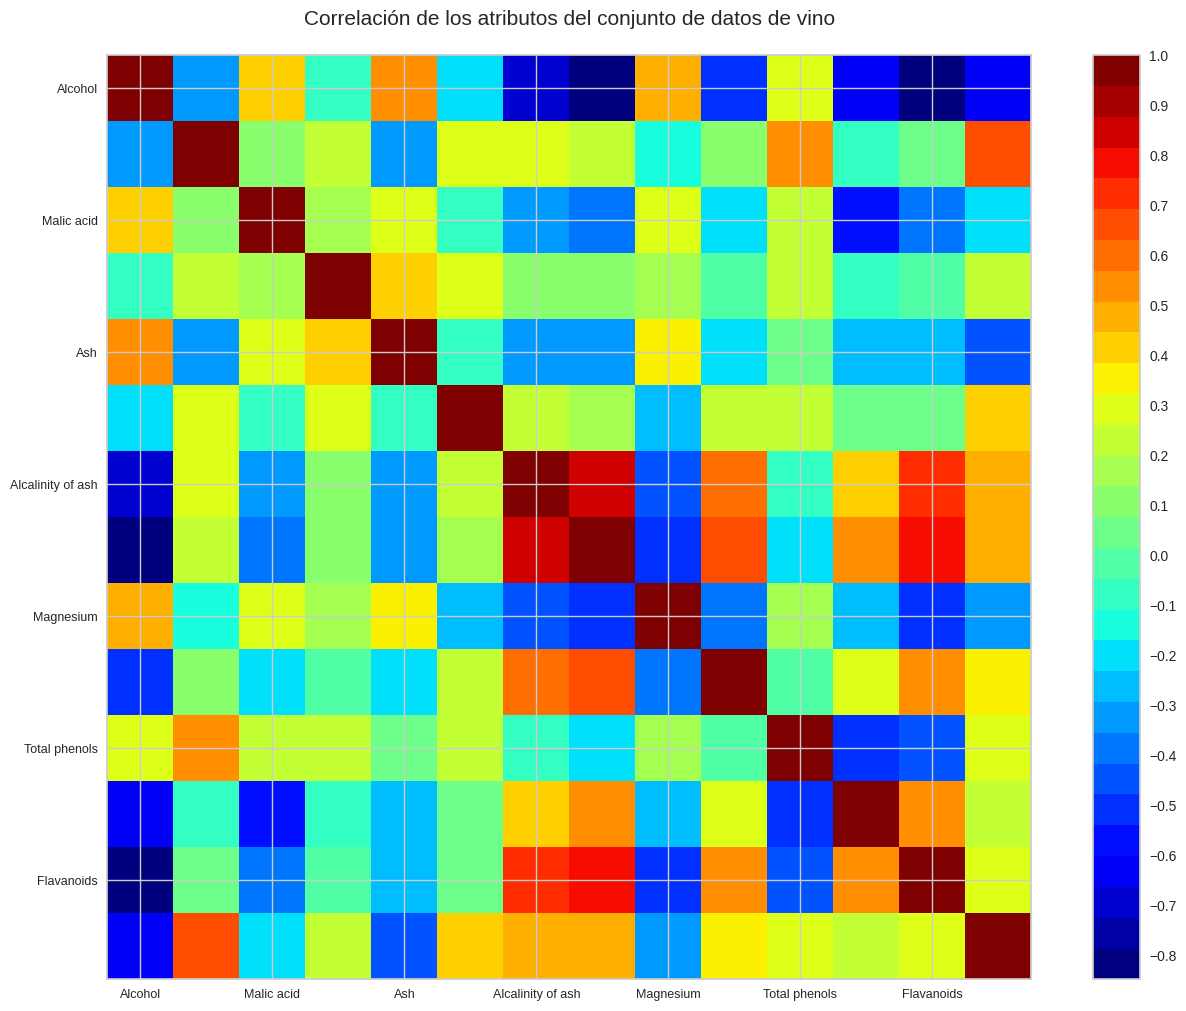

In [49]:
def correlation_matrix(df):
    from matplotlib import pyplot as plt
    from matplotlib import cm as cm

    fig = plt.figure(figsize=(16,12))
    ax1 = fig.add_subplot(111)
    cmap = cm.get_cmap('jet', 30)
    cax = ax1.imshow(df.corr(), interpolation="nearest", cmap=cmap)
    ax1.grid(True)
    plt.title('Correlación de los atributos del conjunto de datos de vino\n',fontsize=15)
    labels=df.columns
    ax1.set_xticklabels(labels,fontsize=9)
    ax1.set_yticklabels(labels,fontsize=9)
    # Add colorbar, make sure to specify tick locations to match desired ticklabels
    fig.colorbar(cax, ticks=[0.1*i for i in range(-11,11)])
    plt.show()

correlation_matrix(df)

# Análisis de Componentes Principales (PCA)

Que hace una reducción de dimensionalidad.

PCA requiere que los datos estén escalados/normalizados para funcionar correctamente.

In [50]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = df.drop('Class',axis=1)
y = df['Class']

X = scaler.fit_transform(X)
dfx = pd.DataFrame(data=X,columns=df.columns[1:])

dfx.head(10)

,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874
5,1.481555,-0.517367,0.305159,-1.289707,0.860705,1.562093,1.366128,-0.176095,0.664217,0.731870,0.406051,0.336606,2.239039
6,1.716255,-0.418624,0.305159,-1.469878,-0.262708,0.328298,0.492677,-0.498407,0.681738,0.083015,0.274431,1.367689,1.729520
7,1.308617,-0.167278,0.890014,-0.569023,1.492625,0.488531,0.482637,-0.417829,-0.597284,-0.003499,0.449924,1.367689,1.745442
8,2.259772,-0.625086,-0.718336,-1.650049,-0.192495,0.808997,0.954502,-0.578985,0.681738,0.061386,0.537671,0.336606,0.949319
9,1.061565,-0.885409,-0.352802,-1.049479,-0.122282,1.097417,1.125176,-1.143031,0.453967,0.935177,0.230557,1.325316,0.949319


Importar y analizar las componentes de PCA

In [51]:
from sklearn.decomposition import PCA

pca = PCA(n_components=12)

dfx_pca = pca.fit(dfx)

print(pca.components_)

[[ 0.1443294  -0.24518758 -0.00205106 -0.23932041  0.14199204  0.39466085
   0.4229343  -0.2985331   0.31342949 -0.0886167   0.29671456  0.37616741
   0.28675223]
 [ 0.48365155  0.22493093  0.31606881 -0.0105905   0.299634    0.06503951
  -0.00335981  0.02877949  0.03930172  0.52999567 -0.27923515 -0.16449619
   0.36490283]
 [-0.20738262  0.08901289  0.6262239   0.61208035  0.13075693  0.14617896
   0.1506819   0.17036816  0.14945431 -0.13730621  0.08522192  0.16600459
  -0.12674592]
 [-0.0178563   0.53689028 -0.21417556  0.06085941 -0.35179658  0.19806835
   0.15229479 -0.20330102  0.39905653  0.06592568 -0.42777141  0.18412074
  -0.23207086]
 [-0.26566365  0.03521363 -0.14302547  0.06610294  0.72704851 -0.14931841
  -0.10902584 -0.50070298  0.13685982 -0.07643678 -0.17361452 -0.10116099
  -0.1578688 ]
 [ 0.21353865  0.53681385  0.15447466 -0.10082451  0.03814394 -0.0841223
  -0.01892002 -0.25859401 -0.53379539 -0.41864414  0.10598274  0.26585107
   0.11972557]
 [-0.05639636  0.420523

Graficar la razón de varianza explicada (Explained variance ratio)

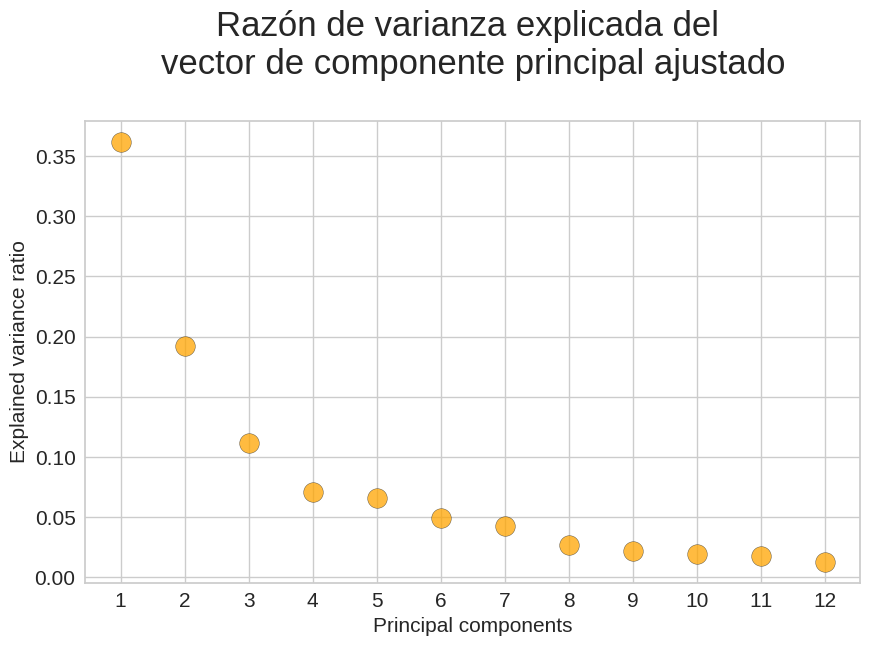

In [52]:
# Con esto puedo ver la razon de mis componentes principales
plt.figure(figsize=(10,6))
plt.scatter(x=[i+1 for i in range(len(dfx_pca.explained_variance_ratio_))],
            y=dfx_pca.explained_variance_ratio_,
           s=200, alpha=0.75,c='orange',edgecolor='k')
plt.grid(True)
plt.title("Razón de varianza explicada del \nvector de componente principal ajustado\n",fontsize=25)
plt.xlabel("Principal components",fontsize=15)
plt.xticks([i+1 for i in range(len(dfx_pca.explained_variance_ratio_))],fontsize=15)
plt.yticks(fontsize=15)
plt.ylabel("Explained variance ratio",fontsize=15)
plt.show()

Este gráfico significa que nuestra componente principal 1 explica aproximadamente el 36% de la varianza total de los datos. La componente 2 explica el 20% adicional. Por lo tanto, si sólo consideramos las dos primeras componentes juntas explicarían el 56% de la varianza total.

Otra forma de visualizar la varianza.
?Cuánta varianza se explica por los componentes principales?

Con la ayuda del siguiente gráfico, podemos decidir trabajar sólo con un número de componentes principales

In [53]:
pca_explained_var = dfx_pca.explained_variance_ratio_
cum_explained_var = pca_explained_var.cumsum()
cum_explained_var

array([0.36198848, 0.55406338, 0.66529969, 0.73598999, 0.80162293,
       0.85098116, 0.89336795, 0.92017544, 0.94239698, 0.96169717,
       0.97906553, 0.99204785])

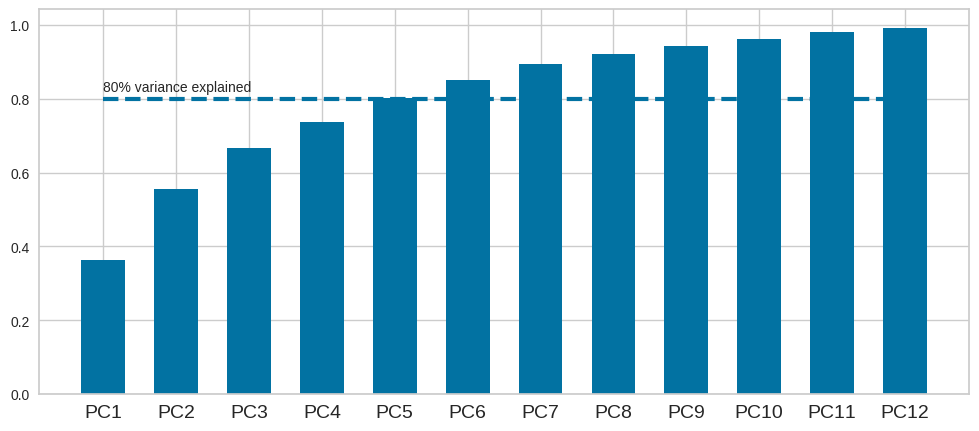

In [54]:
plt.figure(figsize=(12,5))
plt.bar(x=['PC'+str(i) for i in range(1,13)],height=cum_explained_var,width=0.6)
plt.xticks(fontsize=14)
plt.hlines(y=0.8,xmin='PC1',xmax='PC12',linestyles='dashed',lw=3)
plt.text(x='PC1',y=0.82,s="80% variance explained",fontsize=10)
plt.show()

Hasta la variable 5, yo puedo conseguir la explicación de hasta el 80% de los datos

Usar las componentes principales para visualizar nuestros datos.

In [55]:
dfx_trans = pca.transform(dfx)
dfx_trans = pd.DataFrame(data=dfx_trans)
dfx_trans.head(10)

,0,1,2,3,4,5,6,7,8,9,10,11
0,3.316751,1.443463,-0.165739,-0.215631,0.693043,0.223880,0.596427,-0.065139,-0.641443,1.020956,-0.451563,0.540810
1,2.209465,-0.333393,-2.026457,-0.291358,-0.257655,0.927120,0.053776,-1.024416,0.308847,0.159701,-0.142657,0.388238
2,2.516740,1.031151,0.982819,0.724902,-0.251033,-0.549276,0.424205,0.344216,1.177834,0.113361,-0.286673,0.000584
3,3.757066,2.756372,-0.176192,0.567983,-0.311842,-0.114431,-0.383337,-0.643593,-0.052544,0.239413,0.759584,-0.242020
4,1.008908,0.869831,2.026688,-0.409766,0.298458,0.406520,0.444074,-0.416700,-0.326819,-0.078366,-0.525945,-0.216664
5,3.050254,2.122401,-0.629396,-0.515637,-0.632019,-0.123431,0.401654,-0.394893,0.152146,-0.101996,0.405585,-0.379433
6,2.449090,1.174850,-0.977095,-0.065831,-1.027762,0.620121,0.052891,0.371934,0.457016,1.016563,-0.442433,0.141230
7,2.059437,1.608963,0.146282,-1.192608,0.076903,1.439806,0.032376,-0.232979,-0.123370,0.735600,0.293555,0.379663
8,2.510874,0.918071,-1.770969,0.056270,-0.892257,0.129181,0.125285,0.499578,-0.606589,0.174107,-0.508933,-0.635249
9,2.753628,0.789438,-0.984247,0.349382,-0.468553,-0.163392,-0.874352,-0.150580,-0.230489,0.179420,0.012478,0.550327


Visualizando sólo las dos primeras componentes principales de mi conjunto transformado puedo ver la separación

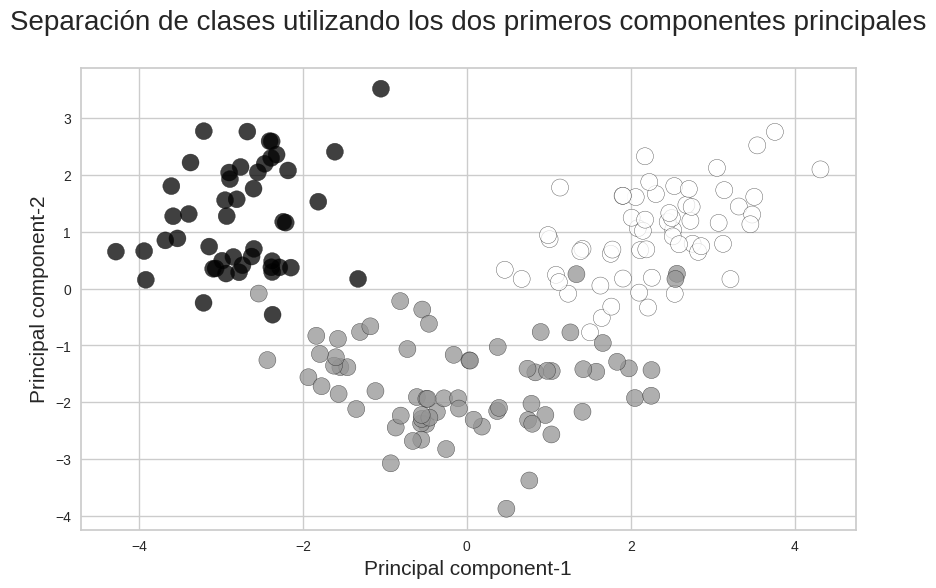

In [56]:
plt.figure(figsize=(10,6))
plt.scatter(dfx_trans[0],dfx_trans[1],c=df['Class'],edgecolors='k',alpha=0.75,s=150)
plt.grid(True)
plt.title("Separación de clases utilizando los dos primeros componentes principales\n",fontsize=20)
plt.xlabel("Principal component-1",fontsize=15)
plt.ylabel("Principal component-2",fontsize=15)
plt.show()

In [57]:
pca = PCA(n_components=5)

dfx_trans2 = pca.fit_transform(dfx)

Reduzir la dimensionalidad para después hacer clustering

In [58]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

km_scores= []
km_silhouette = []

for i in range(2,12):
    km = KMeans(n_clusters=i, random_state=0).fit(dfx_trans2)
    preds = km.predict(dfx_trans2)
    km_scores.append(-km.score(dfx_trans2))

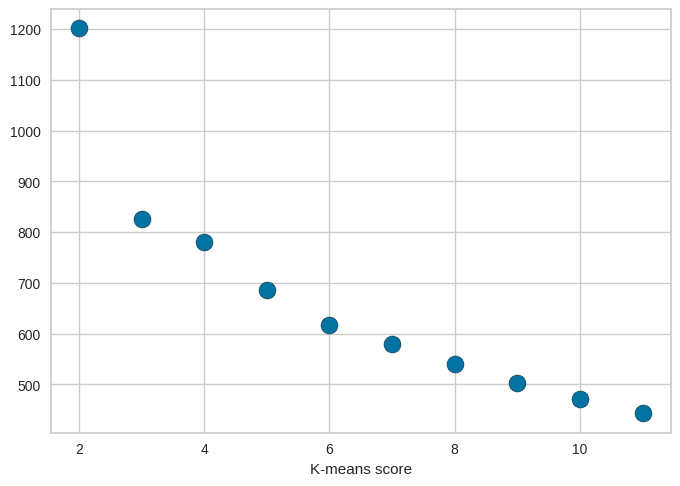

In [59]:
plt.scatter(x=[i for i in range(2,12)],y=km_scores,s=150,edgecolor='k')
plt.grid(True)
plt.xlabel("K-means score")
plt.show()